# Chapter 46 — Optimizers: SGD and AdamW

## Learning goals

Chapter 45 trained a module by updating each parameter manually under `torch.no_grad()`.

PyTorch optimizers package parameter-update rules and any state those rules need.

By the end of this chapter, you should be able to:

1. Explain the distinct jobs of the forward pass, backward pass, and optimizer.
2. Explain how a learning rate affects update size.
3. Clear old gradients with `optimizer.zero_grad()`.
4. Update parameters with `optimizer.step()`.
5. Train the same model with manual gradient descent, `torch.optim.SGD`, and `torch.optim.AdamW`.
6. Explain why this chapter's SGD example is full-batch despite the optimizer's name.
7. Compare SGD and AdamW from identical initialization.
8. Inspect optimizer state before and after an update.
9. Explain decoupled weight decay at a high level.
10. Demonstrate that AdamW still fails with a poor learning rate.

## The big idea

An optimizer is an update rule applied to a collection of parameters.

The model computes predictions, the loss measures error, and backward computes gradients.

Only then can the optimizer use those gradients to change parameters.

A standard training step has this order:

1. Compute predictions and a scalar loss.
2. Clear gradients left by the previous step.
3. Run backward to compute current gradients.
4. Ask the optimizer to update parameters.

## Terms used in this chapter

- An **optimizer** updates parameters using their gradients and an update rule.
- A **learning rate** scales the size of optimizer updates.
- **SGD** means stochastic gradient descent.
- **Full-batch gradient descent** uses every training example for each update.
- **AdamW** adapts updates using running gradient statistics and supports decoupled weight decay.
- **Optimizer state** is extra information maintained across update steps.
- **Weight decay** discourages large parameter magnitudes.
- **Decoupled weight decay** applies shrinkage separately from Adam's gradient-based update.
- `zero_grad()` clears old parameter gradients.
- `backward()` computes gradients but does not update parameters.
- `step()` updates parameters but does not compute gradients.

## Import PyTorch and stay on CPU

Use a fixed seed for fair, reproducible comparisons.

Every model and tensor remains on the CPU.

In [1]:
import torch

device = "cpu"
RANDOM_SEED = 46

print("PyTorch version:", torch.__version__)
print("Course device:", device)
print("Random seed:", RANDOM_SEED)

assert device == "cpu"

PyTorch version: 2.2.2
Course device: cpu
Random seed: 46


## Reuse the line-fitting dataset

Each row contains one input feature.

The target rule is `target = 2 × input + 1`.

In [2]:
input_numbers = torch.tensor(
    [
        [1.0],
        [2.0],
        [3.0],
        [4.0],
    ],
    dtype=torch.float32,
    device=device,
)
target_numbers = torch.tensor(
    [
        [3.0],
        [5.0],
        [7.0],
        [9.0],
    ],
    dtype=torch.float32,
    device=device,
)

print("Inputs:")
print(input_numbers)
print("Targets:")
print(target_numbers)
print("Input shape:", input_numbers.shape)
print("Target shape:", target_numbers.shape)

assert input_numbers.shape == torch.Size([4, 1])
assert target_numbers.shape == torch.Size([4, 1])

Inputs:
tensor([[1.],
        [2.],
        [3.],
        [4.]])
Targets:
tensor([[3.],
        [5.],
        [7.],
        [9.]])
Input shape: torch.Size([4, 1])
Target shape: torch.Size([4, 1])


Each training step in this chapter uses all four rows.

The `torch.optim.SGD` class can support stochastic, mini-batch, or full-batch training; the data-selection strategy determines which one is happening.

## Define the model

Use the same one-input, one-output module as Chapter 45.

The explicit tensor check narrows the broad child-module call type for static checking.

In [3]:
class LineModel(torch.nn.Module):
    linear_layer: torch.nn.Linear

    def __init__(self) -> None:
        super().__init__()
        self.linear_layer = torch.nn.Linear(1, 1)

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values = self.linear_layer(input_values)
        assert isinstance(output_values, torch.Tensor)
        return output_values


torch.manual_seed(RANDOM_SEED)
example_model = LineModel().to(device)

print(example_model)
print("Initial weight:", example_model.linear_layer.weight.item())
print("Initial bias:", example_model.linear_layer.bias.item())

assert example_model.linear_layer.weight.device.type == "cpu"
assert example_model.linear_layer.bias is not None

LineModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
Initial weight: 0.3221660852432251
Initial bias: -0.880027174949646


## The learning rate controls update scale

Plain gradient descent updates one parameter with:

```text
new parameter = old parameter - learning rate × gradient
```

A very small learning rate produces small changes and may train slowly.

A very large learning rate can overshoot useful values or make the loss diverge.

Adaptive optimizers alter the effective update per parameter, but their configured learning rate still matters.

## Manual gradient descent recap

First reproduce the Chapter 45 update without an optimizer object.

This version establishes the baseline that plain SGD should match.

In [4]:
def train_with_manual_gradient_descent(
    learning_rate: float,
    number_of_steps: int,
) -> tuple[LineModel, list[dict[str, float]]]:
    torch.manual_seed(RANDOM_SEED)
    model = LineModel().to(device)
    loss_function = torch.nn.MSELoss()
    parameters = list(model.parameters())
    history: list[dict[str, float]] = []

    for step in range(number_of_steps):
        predictions = model(input_numbers)
        loss = loss_function(predictions, target_numbers)

        for parameter in parameters:
            parameter.grad = None

        loss.backward()

        history.append(
            {
                "step": float(step),
                "loss": loss.item(),
                "weight": model.linear_layer.weight.item(),
                "bias": model.linear_layer.bias.item(),
            }
        )

        with torch.no_grad():
            for parameter in parameters:
                if parameter.grad is None:
                    raise RuntimeError("Expected a gradient after backward.")

                parameter.add_(parameter.grad, alpha=-learning_rate)

    return model, history


manual_model, manual_history = train_with_manual_gradient_descent(
    learning_rate=0.05,
    number_of_steps=100,
)

print("Manual final weight:", manual_model.linear_layer.weight.item())
print("Manual final bias:", manual_model.linear_layer.bias.item())
print("Manual final recorded loss:", manual_history[-1]["loss"])

assert manual_history[-1]["loss"] < manual_history[0]["loss"]

Manual final weight: 2.088332414627075
Manual final bias: 0.7402920722961426
Manual final recorded loss: 0.01160966046154499


The manual loop owns the update logic and must disable gradient tracking around that update.

An optimizer packages this responsibility behind `step()`.

## Separate backward from step

Use one fresh model to observe the roles directly.

Backward changes gradients while leaving parameter values untouched, and `step()` then changes parameter values.

In [5]:
torch.manual_seed(RANDOM_SEED)
role_model = LineModel().to(device)
role_loss_function = torch.nn.MSELoss()
role_optimizer = torch.optim.SGD(
    role_model.parameters(),
    lr=0.05,
)

parameters_before_backward = {
    name: parameter.detach().clone()
    for name, parameter in role_model.named_parameters()
}

role_predictions = role_model(input_numbers)
role_loss = role_loss_function(role_predictions, target_numbers)

role_optimizer.zero_grad(set_to_none=True)
role_loss.backward()

parameters_after_backward = {
    name: parameter.detach().clone()
    for name, parameter in role_model.named_parameters()
}

print("Parameters changed during backward?")
for parameter_name in parameters_before_backward:
    changed = not torch.equal(
        parameters_before_backward[parameter_name],
        parameters_after_backward[parameter_name],
    )
    print(parameter_name, changed)

print("Gradients after backward:")
for parameter_name, parameter in role_model.named_parameters():
    print(parameter_name, parameter.grad)

assert all(
    torch.equal(
        parameters_before_backward[parameter_name],
        parameters_after_backward[parameter_name],
    )
    for parameter_name in parameters_before_backward
)
assert all(parameter.grad is not None for parameter in role_model.parameters())

Parameters changed during backward?
linear_layer.weight False
linear_layer.bias False
Gradients after backward:
linear_layer.weight tensor([[-34.5676]])
linear_layer.bias tensor([-12.1492])


The parameter snapshots are identical before and after backward.

The gradients now exist, so the optimizer has information it can use.

In [6]:
role_optimizer.step()

parameters_after_step = {
    name: parameter.detach().clone()
    for name, parameter in role_model.named_parameters()
}

print("Parameters changed during optimizer.step()?")
for parameter_name in parameters_before_backward:
    changed = not torch.equal(
        parameters_before_backward[parameter_name],
        parameters_after_step[parameter_name],
    )
    print(parameter_name, changed)

assert any(
    not torch.equal(
        parameters_before_backward[parameter_name],
        parameters_after_step[parameter_name],
    )
    for parameter_name in parameters_before_backward
)

Parameters changed during optimizer.step()?
linear_layer.weight True
linear_layer.bias True


PyTorch optimizers perform their updates without building an autograd graph around the update.

Training code therefore does not need to wrap `optimizer.step()` in its own `torch.no_grad()` block.

## Clear accumulated gradients

By default in this environment, explicitly requesting `set_to_none=True` removes stored gradient tensors.

The next backward pass allocates fresh gradients instead of adding to old ones.

In [7]:
print("Gradients before clearing:")
for parameter_name, parameter in role_model.named_parameters():
    print(parameter_name, parameter.grad)

role_optimizer.zero_grad(set_to_none=True)

print()
print("Gradients after clearing:")
for parameter_name, parameter in role_model.named_parameters():
    print(parameter_name, parameter.grad)

assert all(parameter.grad is None for parameter in role_model.parameters())

Gradients before clearing:
linear_layer.weight tensor([[-34.5676]])
linear_layer.bias tensor([-12.1492])

Gradients after clearing:
linear_layer.weight None
linear_layer.bias None


Clearing gradients does not undo the optimizer step.

It only prepares parameter gradient fields for the next backward pass.

## Train with a selected optimizer

Use one function so every optimizer sees the same model class, dataset, initialization seed, and number of steps.

Only the update rule and its learning rate change.

In [8]:
def train_with_optimizer(
    optimizer_name: str,
    learning_rate: float,
    number_of_steps: int,
) -> tuple[LineModel, list[dict[str, float]], torch.optim.Optimizer]:
    torch.manual_seed(RANDOM_SEED)
    model = LineModel().to(device)
    loss_function = torch.nn.MSELoss()

    optimizer: torch.optim.Optimizer

    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
        )
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=0.0,
        )
    else:
        raise ValueError("optimizer_name must be 'SGD' or 'AdamW'.")

    history: list[dict[str, float]] = []

    for step in range(number_of_steps):
        predictions = model(input_numbers)
        loss = loss_function(predictions, target_numbers)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        history.append(
            {
                "step": float(step),
                "loss": loss.item(),
                "weight": model.linear_layer.weight.item(),
                "bias": model.linear_layer.bias.item(),
            }
        )

    return model, history, optimizer

The optimizer does not appear in the forward or loss calculation.

It acts only after backward has populated parameter gradients.

## Train with full-batch SGD

Plain SGD without momentum applies the same update as the manual baseline.

Because both runs start from the same seed, their final tensors and loss histories should match.

In [9]:
sgd_model, sgd_history, sgd_optimizer = train_with_optimizer(
    optimizer_name="SGD",
    learning_rate=0.05,
    number_of_steps=100,
)

print("SGD final weight:", sgd_model.linear_layer.weight.item())
print("SGD final bias:", sgd_model.linear_layer.bias.item())
print("SGD final recorded loss:", sgd_history[-1]["loss"])

torch.testing.assert_close(
    sgd_model.linear_layer.weight,
    manual_model.linear_layer.weight,
)
torch.testing.assert_close(
    sgd_model.linear_layer.bias,
    manual_model.linear_layer.bias,
)
assert [row["loss"] for row in sgd_history] == [row["loss"] for row in manual_history]
assert isinstance(sgd_optimizer, torch.optim.SGD)

SGD final weight: 2.088332414627075
SGD final bias: 0.7402920722961426
SGD final recorded loss: 0.01160966046154499


The exact match confirms that the optimizer object changed code organization rather than the mathematics of this plain-SGD update.

Momentum, weight decay, or other SGD options would change that result.

## Train with AdamW

AdamW tracks running first- and second-moment estimates of gradients.

Set `weight_decay=0.0` so decoupled weight decay is inactive and the comparison focuses on the adaptive update rule.

In [10]:
adamw_model, adamw_history, adamw_optimizer = train_with_optimizer(
    optimizer_name="AdamW",
    learning_rate=0.05,
    number_of_steps=100,
)

print("AdamW final weight:", adamw_model.linear_layer.weight.item())
print("AdamW final bias:", adamw_model.linear_layer.bias.item())
print("AdamW final recorded loss:", adamw_history[-1]["loss"])

assert adamw_history[-1]["loss"] < adamw_history[0]["loss"]
assert adamw_history[-1]["loss"] < 0.01
assert isinstance(adamw_optimizer, torch.optim.AdamW)

AdamW final weight: 2.038588762283325
AdamW final bias: 0.8661876320838928
AdamW final recorded loss: 0.0031779620330780745


Both methods reduce the loss, but their parameter paths differ.

This tiny problem does not establish that one optimizer is generally better than the other.

## Compare final results

Report the two optimizer runs side by side.

The recorded loss belongs to the forward pass immediately before each run's final update.

In [11]:
print("optimizer | final weight | final bias | recorded loss")
print("-" * 63)

for optimizer_name, trained_model, history in (
    ("SGD", sgd_model, sgd_history),
    ("AdamW", adamw_model, adamw_history),
):
    print(
        f"{optimizer_name:>9} | "
        f"{trained_model.linear_layer.weight.item():>12.6f} | "
        f"{trained_model.linear_layer.bias.item():>10.6f} | "
        f"{history[-1]['loss']:>13.6f}"
    )

optimizer | final weight | final bias | recorded loss
---------------------------------------------------------------
      SGD |     2.088332 |   0.740292 |      0.011610
    AdamW |     2.038589 |   0.866188 |      0.003178


## Plot SGD and AdamW losses

This plot compares optimization paths under the same initialization and data.

A logarithmic loss axis keeps both early and late differences visible.

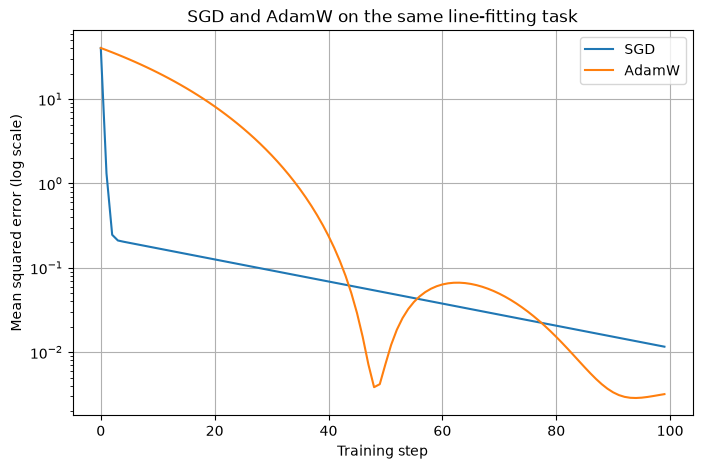

In [12]:
import matplotlib.pyplot as plt

sgd_steps = [int(row["step"]) for row in sgd_history]
sgd_losses = [row["loss"] for row in sgd_history]
adamw_steps = [int(row["step"]) for row in adamw_history]
adamw_losses = [row["loss"] for row in adamw_history]

plt.figure(figsize=(8, 5))
plt.plot(sgd_steps, sgd_losses, label="SGD")
plt.plot(adamw_steps, adamw_losses, label="AdamW")
plt.yscale("log")
plt.xlabel("Training step")
plt.ylabel("Mean squared error (log scale)")
plt.title("SGD and AdamW on the same line-fitting task")
plt.legend()
plt.grid(True)
plt.show()

The curves differ because AdamW transforms the gradient using its running statistics.

A single toy curve should not be used to choose an optimizer for every model or dataset.

## Inspect optimizer state

Plain SGD without momentum needs no numeric per-parameter running statistics.

PyTorch 2.2.2 still stores a `momentum_buffer` placeholder with value `None`.

AdamW creates running statistics after its first step, so the completed AdamW optimizer has state for both parameter tensors.

In [13]:
sgd_momentum_buffers = [
    parameter_state.get("momentum_buffer")
    for parameter_state in sgd_optimizer.state.values()
]

print("Plain SGD momentum placeholders:", sgd_momentum_buffers)
print("AdamW parameter-state entries:", len(adamw_optimizer.state))

adamw_weight_state = adamw_optimizer.state[adamw_model.linear_layer.weight]

print("AdamW weight-state fields:", sorted(adamw_weight_state))
print("First-moment shape:", adamw_weight_state["exp_avg"].shape)
print("Second-moment shape:", adamw_weight_state["exp_avg_sq"].shape)

assert all(buffer is None for buffer in sgd_momentum_buffers)
assert len(adamw_optimizer.state) == 2
assert set(adamw_weight_state) == {
    "step",
    "exp_avg",
    "exp_avg_sq",
}

Plain SGD momentum placeholders: [None, None]
AdamW parameter-state entries: 2
AdamW weight-state fields: ['exp_avg', 'exp_avg_sq', 'step']
First-moment shape: torch.Size([1, 1])
Second-moment shape: torch.Size([1, 1])


The moment tensors match the shape of the parameter they summarize.

This extra state consumes memory and influences later updates.

## Weight decay is a separate AdamW feature

With nonzero `weight_decay`, AdamW shrinks parameters separately from its adaptive gradient update.

This decoupling is the reason for the `W` in AdamW.

Whether weight decay is useful, and which parameters should receive it, depends on the model and training setup.

This chapter keeps it at zero so regularization does not complicate the optimizer comparison.

## AdamW is not magic

A poor learning rate can still make adaptive optimization unstable.

Train AdamW with an intentionally excessive learning rate while keeping every other choice fixed.

In [14]:
bad_adamw_model, bad_adamw_history, _ = train_with_optimizer(
    optimizer_name="AdamW",
    learning_rate=10.0,
    number_of_steps=30,
)

print("step | good AdamW loss | bad-rate AdamW loss")
print("-" * 49)

for step in range(5):
    print(
        f"{step:>4} | "
        f"{adamw_history[step]['loss']:>15.6f} | "
        f"{bad_adamw_history[step]['loss']:>19.6f}"
    )

print()
print("Good AdamW loss after 30 steps:", adamw_history[29]["loss"])
print("Bad-rate AdamW loss after 30 steps:", bad_adamw_history[-1]["loss"])

assert bad_adamw_history[-1]["loss"] > adamw_history[29]["loss"] * 5.0
assert abs(bad_adamw_model.linear_layer.weight.item() - 2.0) > 0.5

step | good AdamW loss | bad-rate AdamW loss
-------------------------------------------------
   0 |       40.419819 |           40.419819
   1 |       38.117729 |          923.250977
   2 |       35.885056 |           75.034790
   3 |       33.722931 |          191.072662
   4 |       31.632401 |          498.358521

Good AdamW loss after 30 steps: 2.537593364715576
Bad-rate AdamW loss after 30 steps: 25.89159393310547


The excessive rate causes large oscillations and a much worse fit.

AdamW adapts updates, but the configured learning rate still sets their overall scale.

## Plot learning-rate sensitivity

Compare the reasonable and excessive AdamW runs over the same first 30 steps.

The logarithmic axis accommodates the bad run's large spikes.

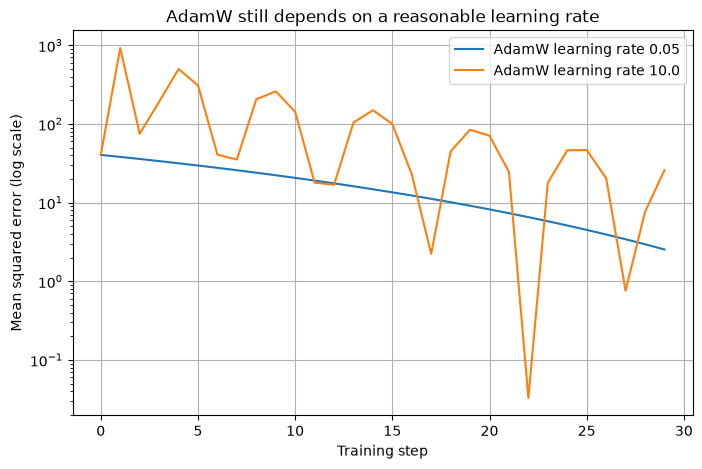

In [15]:
comparison_steps = list(range(30))
good_adamw_first_30_losses = [row["loss"] for row in adamw_history[:30]]
bad_adamw_losses = [row["loss"] for row in bad_adamw_history]

plt.figure(figsize=(8, 5))
plt.plot(
    comparison_steps,
    good_adamw_first_30_losses,
    label="AdamW learning rate 0.05",
)
plt.plot(
    comparison_steps,
    bad_adamw_losses,
    label="AdamW learning rate 10.0",
)
plt.yscale("log")
plt.xlabel("Training step")
plt.ylabel("Mean squared error (log scale)")
plt.title("AdamW still depends on a reasonable learning rate")
plt.legend()
plt.grid(True)
plt.show()

The optimizer class alone does not guarantee successful training.

Learning rate, initialization, data, loss, model architecture, and other settings all interact.

## Verify gradient accumulation without zero_grad

Use two fresh forward graphs while intentionally skipping gradient clearing.

The second backward pass adds another copy of the same gradient because the parameters have not changed.

In [16]:
torch.manual_seed(RANDOM_SEED)
accumulation_model = LineModel().to(device)
accumulation_loss_function = torch.nn.MSELoss()
accumulation_optimizer = torch.optim.SGD(
    accumulation_model.parameters(),
    lr=0.05,
)

first_accumulation_loss = accumulation_loss_function(
    accumulation_model(input_numbers),
    target_numbers,
)
first_accumulation_loss.backward()

first_gradients = {
    name: parameter.grad.detach().clone()
    for name, parameter in accumulation_model.named_parameters()
    if parameter.grad is not None
}

second_accumulation_loss = accumulation_loss_function(
    accumulation_model(input_numbers),
    target_numbers,
)
second_accumulation_loss.backward()

second_gradients = {
    name: parameter.grad.detach().clone()
    for name, parameter in accumulation_model.named_parameters()
    if parameter.grad is not None
}

print("name | first gradient | accumulated gradient")
print("-" * 60)
for parameter_name in first_gradients:
    print(
        parameter_name,
        first_gradients[parameter_name],
        second_gradients[parameter_name],
    )
    torch.testing.assert_close(
        second_gradients[parameter_name],
        2.0 * first_gradients[parameter_name],
    )

accumulation_optimizer.zero_grad(set_to_none=True)

assert all(parameter.grad is None for parameter in accumulation_model.parameters())

name | first gradient | accumulated gradient
------------------------------------------------------------
linear_layer.weight tensor([[-34.5676]]) tensor([[-69.1353]])
linear_layer.bias tensor([-12.1492]) tensor([-24.2984])


The optimizer was present but did not prevent accumulation automatically.

Training code must call `zero_grad()` at the intended boundary between gradient calculations.

## The standard optimizer-based step

The reusable sequence is:

```python
predictions = model(input_numbers)
loss = loss_function(predictions, target_numbers)

optimizer.zero_grad(set_to_none=True)
loss.backward()
optimizer.step()
```

The forward pass and loss create the graph.

`zero_grad()` prepares gradient storage, backward fills it, and `step()` consumes those gradients to update parameters.

## What not to do

- Do not expect an optimizer to compute gradients.
- Do not call `step()` before gradients exist.
- Do not forget to clear gradients between ordinary training steps.
- Do not assume `zero_grad()` reverses a parameter update.
- Do not assume AdamW chooses a good learning rate automatically.
- Do not compare optimizer curves from different random initializations unless that difference is intentional.
- Do not treat one toy experiment as evidence that an optimizer is universally superior.
- Do not add CUDA assumptions to this CPU-only course.

## Gotchas

- `torch.optim.SGD` can be used with full batches, mini-batches, or individual examples.
- Backward computes gradients, while the optimizer step changes parameter values.
- `zero_grad(set_to_none=True)` usually leaves `.grad` as `None` until the next backward pass.
- Plain SGD without momentum matches the manual gradient-descent update.
- AdamW stores extra state for its adaptive rule.
- AdamW's decoupled weight decay is inactive when `weight_decay=0`.
- Every optimizer still depends on hyperparameters such as the learning rate.

## Takeaways

An optimizer packages a parameter-update rule.

The model and loss build a scalar objective, backward computes gradients, and the optimizer uses those gradients.

Plain SGD reproduced the manual update exactly when initialization and settings matched.

AdamW used running gradient statistics and followed a different optimization path.

The standard step is:

1. Run the model and compute a scalar loss.
2. Clear old gradients.
3. Call `loss.backward()`.
4. Call `optimizer.step()`.

AdamW can be useful for deep learning, but it is not magic and still needs sensible training choices.

## What comes next

The next chapter applies modules, autograd, and optimizers to multiclass classification.

The model will produce one logit per class, and PyTorch cross-entropy will turn those logits and integer targets into a scalar training loss.